# Practical 2. Does the brain know the speed?

In the study, a model reads the brain images of a rat. The model predicts the speed of the rat.

You get the test data of this model. It has 6417 time points. Each point has the true speed and the predicted speed.

You will fit a line through this data and measure how good the prediction is. Then you will see what happens to the slope when you center and scale the data.

How to work:

- Read the question.
- Write your code in the cell that shows `# YOUR CODE HERE`.
- Run the check cell below your code. No error means your answer is correct.
- Use the variable names that the question gives. The checks look for these names.
- There is no dumb question :)

In [1]:
from pathlib import Path
from urllib.request import urlretrieve

FILES = {
    "decode_regressor.tsv": "69e77741a86f113b3dfd83fa",
    "decode_dummy.tsv": "69e77775a86f113b3dfd841d",
}
DATA = Path("data")
DATA.mkdir(exist_ok=True)
for name, osf_id in FILES.items():
    if not (DATA / name).exists():
        print("downloading", name)
        urlretrieve(f"https://osf.io/download/{osf_id}/", DATA / name)
print("data ready")

data ready


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

## 1. Load the table

Read the file `data/decode_regressor.tsv` into a DataFrame. Call the DataFrame `decoded`. The file uses tabs between values. Show the first rows of `decoded`.

In [3]:
decoded = pd.read_csv("data/decode_regressor.tsv", sep="\t")
decoded.head()

,predicted,actual
0,28.061979,7.002245
1,27.068164,7.180451
2,25.917650,7.278370
3,24.610826,7.285528
4,23.158791,7.196360


In [4]:
assert decoded.shape == (6417, 2), "did you pass sep='\\t'?"
assert list(decoded.columns) == ["predicted", "actual"]

## 2. Describe both columns

Compute the mean and the standard deviation of the column `actual`, and store them in `mean_actual` and `std_actual`. Do the same for the column `predicted`: `mean_predicted` and `std_predicted`.

In [5]:
mean_actual, std_actual = decoded["actual"].mean(), decoded["actual"].std()
mean_predicted, std_predicted = decoded["predicted"].mean(), decoded["predicted"].std()
print(mean_actual, std_actual, mean_predicted, std_predicted)

9.802587035466107 10.091975694874838 7.767669328388063 9.3141597177204


In [6]:
assert np.isclose(mean_actual, 9.803, atol=0.01)
assert np.isclose(std_actual, 10.092, atol=0.01)
assert np.isclose(mean_predicted, 7.768, atol=0.01)
assert np.isclose(std_predicted, 9.314, atol=0.01)

## 3. Look at the cloud

Make a scatter plot of `decoded`. Put `actual` on the x-axis. Put `predicted` on the y-axis. Use small points with some transparency. Label both axes with the units.

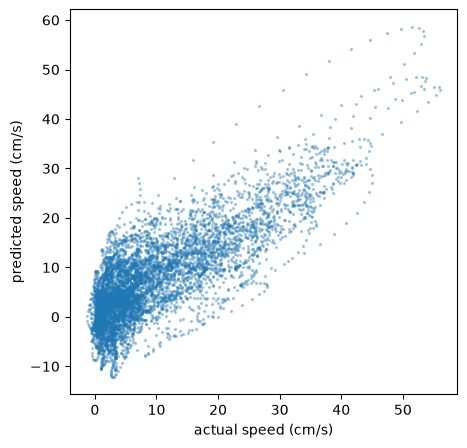

In [7]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(decoded["actual"], decoded["predicted"], s=2, alpha=0.3)
ax.set_xlabel("actual speed (cm/s)")
ax.set_ylabel("predicted speed (cm/s)")
plt.show()

## 4. Fit a line

Use `stats.linregress(x, y)` with `actual` as x and `predicted` as y. Store the slope, the intercept, and the `rvalue` in `slope`, `intercept`, and `r`.

In [8]:
fit = stats.linregress(decoded["actual"], decoded["predicted"])
slope, intercept, r = fit.slope, fit.intercept, fit.rvalue
print(slope, intercept, r)

0.7473676841940903 0.4415325565807455 0.8097795971516388


In [9]:
assert np.isclose(slope, 0.7474, atol=0.001), "x is actual, y is predicted"
assert np.isclose(intercept, 0.4415, atol=0.001)
assert np.isclose(r, 0.8098, atol=0.001)

## 5. Draw the line, look at the residuals

Draw the line, with `intercept` and `slope`, over the cloud of points. Then compute the residuals: `residuals = predicted - (intercept + slope * actual)`. Store them in `residuals`. Show a histogram of `residuals`.

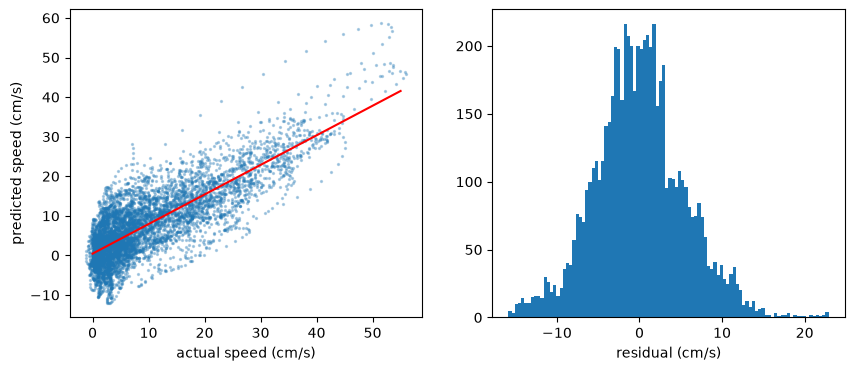

In [10]:
x_line = np.array([0, 55])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.scatter(decoded["actual"], decoded["predicted"], s=2, alpha=0.3)
ax1.plot(x_line, intercept + slope * x_line, color="red")
ax1.set_xlabel("actual speed (cm/s)")
ax1.set_ylabel("predicted speed (cm/s)")
residuals = decoded["predicted"] - (intercept + slope * decoded["actual"])
ax2.hist(residuals, bins=100)
ax2.set_xlabel("residual (cm/s)")
plt.show()

In [11]:
assert abs(residuals.mean()) < 1e-6, "residuals of a least-squares line average to zero"
assert np.isclose(residuals.std(), 5.465, atol=0.01)

## 6. Center and scale

Write a function `zscore(values)`. The function returns `(values - values.mean()) / values.std()`. Apply `zscore` to the columns `actual` and `predicted`. Store the results in `actual_z` and `predicted_z`.

In [12]:
def zscore(values):
    return (values - values.mean()) / values.std()

actual_z = zscore(decoded["actual"])
predicted_z = zscore(decoded["predicted"])

In [13]:
assert abs(actual_z.mean()) < 1e-9 and np.isclose(actual_z.std(), 1.0, atol=1e-3), "mean 0, std 1"
assert abs(predicted_z.mean()) < 1e-9 and np.isclose(predicted_z.std(), 1.0, atol=1e-3)

## 7. Fit again

Fit the line on `actual_z` and `predicted_z`. Store the slope, the intercept, and the `rvalue` in `slope_z`, `intercept_z`, and `r_z`. Compare `slope_z` with `r` from exercise 4.

In [14]:
fit_z = stats.linregress(actual_z, predicted_z)
slope_z, intercept_z, r_z = fit_z.slope, fit_z.intercept, fit_z.rvalue
print(slope_z, intercept_z, r_z, r)

0.8097795971516387 5.565326661415061e-17 0.8097795971516385 0.8097795971516388


In [15]:
assert np.isclose(intercept_z, 0, atol=1e-9), "centered data: the line passes through the origin"
assert np.isclose(r_z, r), "scaling does not change r"
assert np.isclose(slope_z, r), "the slope of the standardized fit IS the correlation"

### Why

The slope of a least-squares line equals `r * std(y) / std(x)`. After you z-score the data, both standard deviations equal 1. So the slope equals `r`. The correlation `r` is the slope of the line in units of standard deviation.

## 8. A control model

Repeat exercises 1, 4 and 7 for the file `data/decode_dummy.tsv`. This control model does not see the cleaned brain images. It only sees the confound signals that we remove from the brain data before we train the real model. Load it into `decoded_dummy`. Fit a line and store `slope_d`, `intercept_d` and `r_d`. Z-score both columns and fit again. Store the slope in `slope_dz`.

In [16]:
decoded_dummy = pd.read_csv("data/decode_dummy.tsv", sep="\t")
fit_d = stats.linregress(decoded_dummy["actual"], decoded_dummy["predicted"])
slope_d, intercept_d, r_d = fit_d.slope, fit_d.intercept, fit_d.rvalue
slope_dz = stats.linregress(zscore(decoded_dummy["actual"]), zscore(decoded_dummy["predicted"])).slope
print(slope_d, r_d, slope_dz)

0.1357270828063995 0.3544485073252207 0.3544485073252207


In [17]:
assert decoded_dummy.shape == (6417, 2)
assert np.isclose(r_d, 0.354, atol=0.005)
assert np.isclose(slope_dz, r_d), "the same identity holds for any cloud"
assert r_d < r, "the brain model is better than the control"

## 9. Side by side

Make one figure with two scatter plots: the brain model from `decoded` and the control model from `decoded_dummy`. Use the same axis limits for both plots. Draw the fitted line on each plot. Put the value of `r` in the title of each plot.

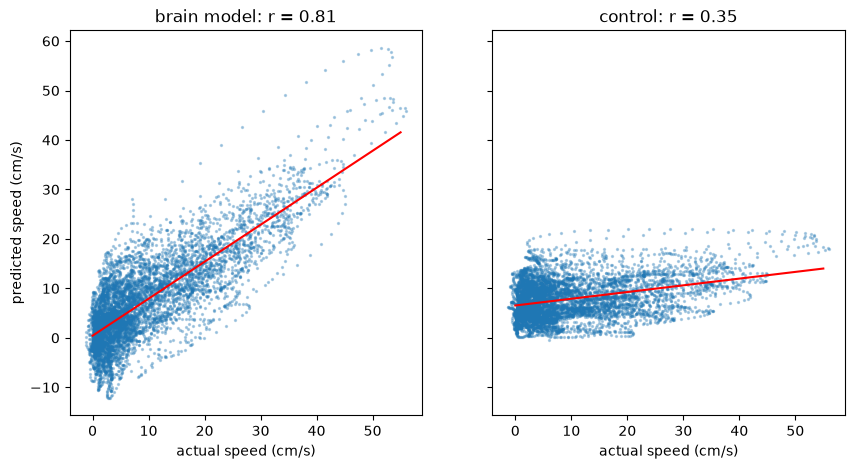

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
for ax, frame, name, this_fit in [(axes[0], decoded, "brain model", fit), (axes[1], decoded_dummy, "control", fit_d)]:
    ax.scatter(frame["actual"], frame["predicted"], s=2, alpha=0.3)
    ax.plot(x_line, this_fit.intercept + this_fit.slope * x_line, color="red")
    ax.set_title(f"{name}: r = {this_fit.rvalue:.2f}")
    ax.set_xlabel("actual speed (cm/s)")
axes[0].set_ylabel("predicted speed (cm/s)")
plt.show()

## 10. Bonus: r-squared two ways

Compute `r2_a = r ** 2`. Compute `r2_b = 1 - residuals.var() / decoded['predicted'].var()`. The two values are close.

In [19]:
r2_a = r ** 2
r2_b = 1 - residuals.var() / decoded["predicted"].var()
print(r2_a, r2_b)

0.6557429959630705 0.6557429959630703


In [20]:
assert np.isclose(r2_a, r2_b, atol=1e-3), "r squared is the fraction of variance the line explains"

## Done

You fitted a line, read its slope and its `r`, and saw that `r` is the slope in units of standard deviation.

The statistics course starts here, with the same line. It asks how sure we can be about this line.